Estimating Mean Radiant Temperature from LST and shadows at a precise moment, at 1m scale

MRT = (LST + 10.2)/0.92 x (1-0.5 x 1shadows)

### General paths, libraries

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from pyproj import CRS
import pandas as pd
from rasterio import features
from rasterio.transform import from_origin
from rasterio.windows import from_bounds
from rasterio.warp import reproject, Resampling
from rasterstats import zonal_stats
import os
from scipy.ndimage import distance_transform_edt
from rasterio.windows import Window
from rasterio.vrt import WarpedVRT

In [2]:
# user-defined paths
base_dir = '../../../datos-notebooks/2.global-data-bologna/'
census_areas_name = 'sezioni-di-censimento-anno-2011.geojson'
city_boundary = 'bologne_boundary.geojson'

trees_shadows_name = 'shadows_trees_2024-08-09_095810.gpkg'
building_shadows_name = 'shadows_buildings_2024-08-09_095810.gpkg'
other_shadows_name = 'origini-di-bologna-portici.geojson'
crs_epsg = 32632  # Projected CRS EPSG code, depending on the city

In [3]:
# derived paths
shadows_vector_path = os.path.join(base_dir, 'MRT-prediction/shadows_all_2024-08-09-095810.gpkg')
shadow_raster_path = os.path.join(base_dir, 'MRT-prediction/shadows_all_2024-08-09-095810_1m.tif')  
census_areas_path = os.path.join(base_dir, 'vectors/',census_areas_name)
bound_path = os.path.join(base_dir, 'vectors/',city_boundary)

lst_predicted_fromHR_path = os.path.join(base_dir, 'LST-prediction/LST_predicted_RF_fromHRdata.tif') 
lst_predicted_fromHR_1m_path = os.path.join(base_dir, 'LST-prediction/LST_predicted_fromHR_1m.tif')

lst_predicted_fromglobal_path = os.path.join(base_dir, 'LST-prediction/LST_predicted_RF.tif') 
lst_predicted_fromglobal_1m_path = os.path.join(base_dir, 'LST-prediction/LST_predicted_fromglobal_1m.tif')

mrt_fromHR_output_path = os.path.join(base_dir, 'MRT-prediction/MRT_fromHR_1m.tif')
mrt_fromglobal_output_path = os.path.join(base_dir, 'MRT-prediction/MRT_fromglobal_1m.tif')

In [4]:
buildings_raster_path_1m = os.path.join(base_dir, 'objects-height/rasterized-1m/buildings_footprint_1m.tif')
distance_building_raster_path = os.path.join(base_dir, 'objects-height/rasterized-1m/buildings_distance.tif')


### Preparing shadows (rasterizing-1m)

In [ ]:
shadow1 = gpd.read_file(os.path.join(base_dir, 'MRT-prediction/shadows/', building_shadows_name)) 
shadow1 = shadow1.to_crs(CRS.from_epsg(crs_epsg))
shadow2 = gpd.read_file(os.path.join(base_dir, 'MRT-prediction/shadows/', trees_shadows_name)) 
shadow2 = shadow2.to_crs(CRS.from_epsg(crs_epsg))
shadow3 = gpd.read_file(os.path.join(base_dir, 'MRT-prediction/shadows/', other_shadows_name)) 
shadow3 = shadow3.to_crs(CRS.from_epsg(crs_epsg))

# join all the shadow files in one -- 
shadow = gpd.GeoDataFrame(pd.concat([shadow1, shadow2, shadow3], ignore_index=True), crs=shadow1.crs)

#preparing dataset for rasterizing -- 30m aprox
shadow = shadow[~shadow.geometry.is_empty] # Drop empty geometries
shadow = shadow[shadow.geometry.notnull()] # Drop null geometries
shadow["geometry"] = shadow.buffer(0) # Fix invalid geometries (buffer(0) trick)
shadow = shadow[~shadow.geometry.is_empty] # Drop again if something became empty

# clip to city boundary
# we computed the shadows including trees in a 100m offset of the city boundary, 
# now we clip the shadows that fit into the city boundary
boundary = gpd.read_file(bound_path)
boundary = boundary.to_crs(shadow.crs)
shadow = shadow.clip(boundary) 

shadow.to_file(shadows_vector_path, layer="shadow", driver="GPKG")



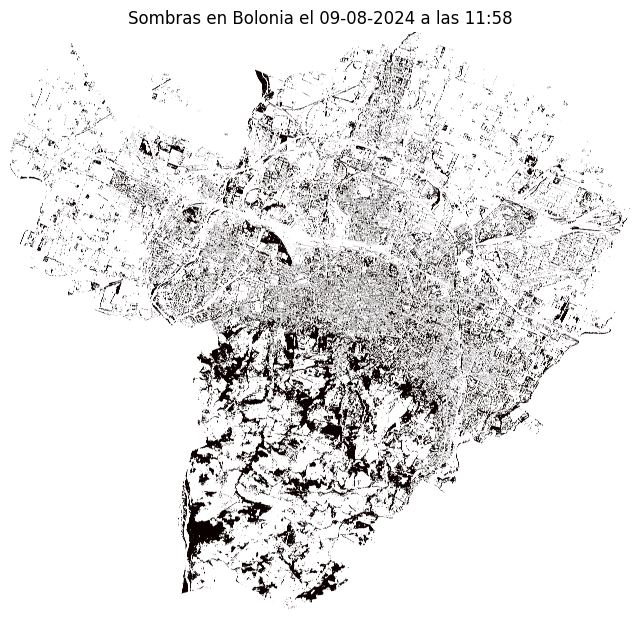

In [7]:
with rasterio.open(shadow_raster_path) as src:
    mrt_plot = src.read(1) 

plt.figure(figsize=(8,8)) 
img = plt.imshow(mrt_plot, cmap="hot_r", origin="upper") #complete image, 1 minute aprox
plt.axis("off")
plt.title("Sombras en Bolonia el 09-08-2024 a las 11:58")
plt.show()

In [ ]:
#rasterizing 
res = 1  # pixel size in meters
minx, miny, maxx, maxy = shadow.total_bounds # bounds of the vector layer

# number of rows and cols
width  = int((maxx - minx) / res)
height = int((maxy - miny) / res)

# affine transform (top-left origin)
transform = from_origin(minx, maxy, res, res)

# geometry -> value (burn = 1)
shapes = ((geom, 1) for geom in shadow.geometry if geom is not None)

# rasterization
raster = features.rasterize(
    shapes=shapes,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype="uint8"
)

# --- Save raster ---

with rasterio.open(
    shadow_raster_path,
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype=raster.dtype,
    crs=shadow.crs,
    transform=transform
) as dst:
    dst.write(raster, 1)

In [1]:
with rasterio.open(shadow_raster_path) as src:
    shadow_raster = src.read(1)        
    transform = src.transform  
    crs = src.crs              

NameError: name 'rasterio' is not defined

In [ ]:
# Plot

xmin, ymin = 680000, 4945000
xmax, ymax = 682000, 4946000

win = from_bounds(xmin, ymin, xmax, ymax, transform) # Convert bounds to pixel window

# Slices
r0, c0 = int(win.row_off), int(win.col_off)
r1 = r0 + int(win.height)
c1 = c0 + int(win.width)

# Extract window
r_win = shadow_raster[r0:r1, c0:c1]

# Plot
plt.figure(figsize=(6,6))
plt.imshow(r_win, cmap="gray", origin="upper")
plt.title("Shadow raster window")
plt.axis("off")
plt.show()


### Preparing raster of distance to buildings

In [9]:
CHUNK_SIZE = 5000   # pixels per block
OVERLAP = 500       # overlap to avoid edge artifacts

with rasterio.open(buildings_raster_path_1m) as src:
    transform = src.transform
    profile = src.profile
    height, width = src.height, src.width
    pixel_size_x = abs(transform.a)
    pixel_size_y = abs(transform.e)


profile.update(
    dtype="float32",
    count=1,
    nodata=-9999,
    compress="lzw",
    tiled=True,
    blockxsize=512,
    blockysize=512,
    bigtiff="YES"   # <-- this is what was missing
)


with rasterio.open(distance_building_raster_path, "w", **profile) as dst:
    
    for row_off in range(0, height, CHUNK_SIZE):
        for col_off in range(0, width, CHUNK_SIZE):
            
            # Window with overlap
            row_start = max(0, row_off - OVERLAP)
            col_start = max(0, col_off - OVERLAP)
            row_end   = min(height, row_off + CHUNK_SIZE + OVERLAP)
            col_end   = min(width,  col_off + CHUNK_SIZE + OVERLAP)
            
            win = Window(col_start, row_start,
                         col_end - col_start,
                         row_end - row_start)
            
            with rasterio.open(buildings_raster_path_1m) as src:
                chunk = src.read(1, window=win).astype("float32")
            
            # Compute distance in the chunk
            no_building_mask = chunk == 0
            dist_chunk = distance_transform_edt(
                no_building_mask,
                sampling=(pixel_size_y, pixel_size_x)
            ).astype("float32")
            
            # Trim overlap to write only the central part
            r0 = row_off - row_start  # offset within the chunk
            c0 = col_off - col_start
            r1 = r0 + min(CHUNK_SIZE, height - row_off)
            c1 = c0 + min(CHUNK_SIZE, width  - col_off)
            
            dist_core = dist_chunk[r0:r1, c0:c1]
            
            write_win = Window(col_off, row_off, dist_core.shape[1], dist_core.shape[0])
            dst.write(dist_core, 1, window=write_win)
            
            print(f"Processed block ({row_off}, {col_off})")

Procesado bloque (0, 0)
Procesado bloque (0, 5000)
Procesado bloque (0, 10000)
Procesado bloque (0, 15000)
Procesado bloque (0, 20000)
Procesado bloque (0, 25000)
Procesado bloque (0, 30000)
Procesado bloque (5000, 0)
Procesado bloque (5000, 5000)
Procesado bloque (5000, 10000)
Procesado bloque (5000, 15000)
Procesado bloque (5000, 20000)
Procesado bloque (5000, 25000)
Procesado bloque (5000, 30000)
Procesado bloque (10000, 0)
Procesado bloque (10000, 5000)
Procesado bloque (10000, 10000)
Procesado bloque (10000, 15000)
Procesado bloque (10000, 20000)
Procesado bloque (10000, 25000)
Procesado bloque (10000, 30000)
Procesado bloque (15000, 0)
Procesado bloque (15000, 5000)
Procesado bloque (15000, 10000)
Procesado bloque (15000, 15000)
Procesado bloque (15000, 20000)
Procesado bloque (15000, 25000)
Procesado bloque (15000, 30000)
Procesado bloque (20000, 0)
Procesado bloque (20000, 5000)
Procesado bloque (20000, 10000)
Procesado bloque (20000, 15000)
Procesado bloque (20000, 20000)
Proc

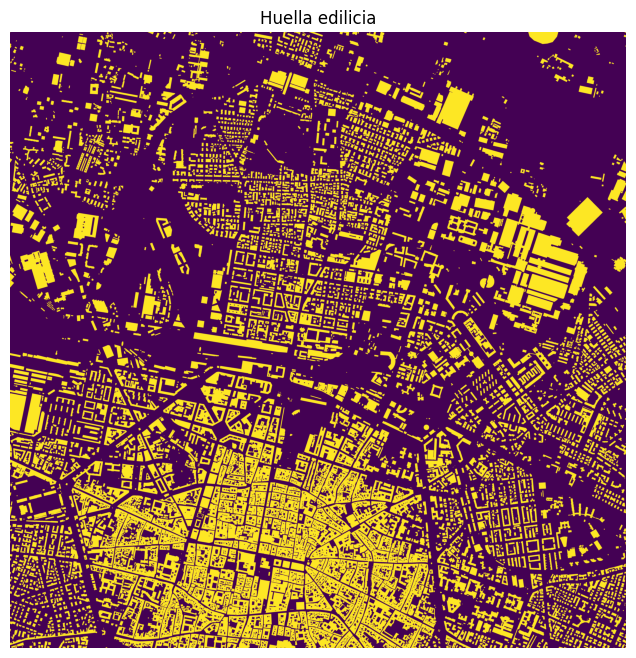

In [11]:
with rasterio.open(buildings_raster_path_1m) as src:
    window = rasterio.windows.Window(col_off=15000, row_off=7000, width=8000, height=8000)  # adjust as needed
    data = src.read(1, window=window)

plt.figure(figsize=(8,8))
plt.imshow(data, cmap='viridis')
plt.axis('off')
plt.title('Huella edilicia')
plt.show()

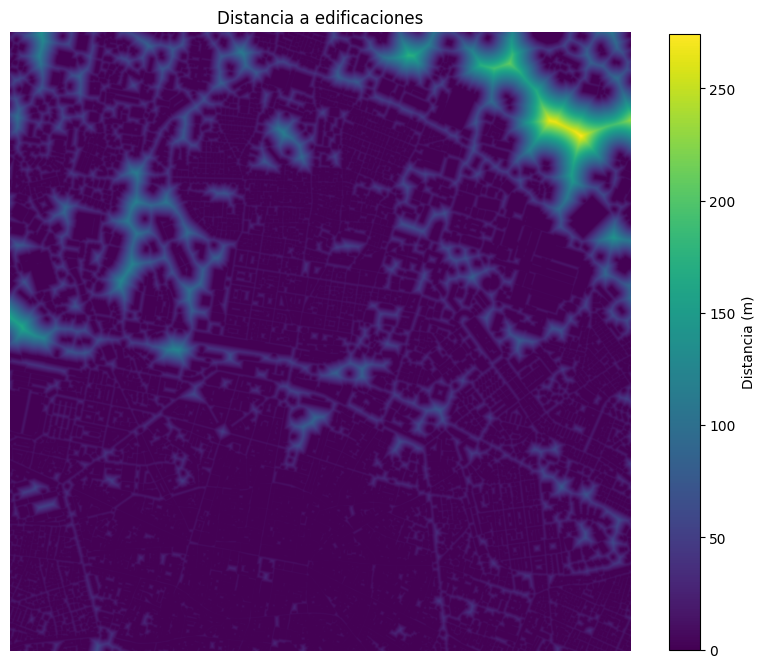

In [12]:
with rasterio.open(distance_building_raster_path) as src:
    window = rasterio.windows.Window(col_off=15000, row_off=7000, width=8000, height=8000)  # adjust as needed
    data = src.read(1, window=window)

plt.figure(figsize=(10,10))
plt.imshow(data, cmap='viridis')
plt.colorbar(label='Distancia (m)', shrink=0.8)
plt.axis('off')
plt.title('Distancia a edificaciones')
plt.show()

### Upscaling modeled LST to shadow resolution (1m)

In [6]:
with rasterio.open(shadow_raster_path) as ref:
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_shape = (ref.height, ref.width)

# Reproject LST predicted from HR data to 1m resolution matching shadow raster
with rasterio.open(lst_predicted_fromHR_path) as src:
    lst_1m = np.empty(ref_shape, dtype=np.float32)

    reproject(
        source=rasterio.band(src, 1),
        destination=lst_1m,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        resampling=Resampling.bilinear  # good for continuous variables like LST
    )

    meta = src.meta.copy()
    meta.update({
        "height": ref_shape[0],
        "width": ref_shape[1],
        "transform": ref_transform,
        "crs": ref_crs,
        "dtype": "float32"
    })

    with rasterio.open(lst_predicted_fromHR_1m_path, "w", **meta) as dst:
        dst.write(lst_1m, 1)
        
# Reproject LST predicted from global data to 1m resolution matching shadow raster
with rasterio.open(lst_predicted_fromglobal_path) as src:
    lst_1m = np.empty(ref_shape, dtype=np.float32)

    reproject(
        source=rasterio.band(src, 1),
        destination=lst_1m,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        resampling=Resampling.bilinear  # good for continuous variables like LST
    )

    meta = src.meta.copy()
    meta.update({
        "height": ref_shape[0],
        "width": ref_shape[1],
        "transform": ref_transform,
        "crs": ref_crs,
        "dtype": "float32"
    })

    with rasterio.open(lst_predicted_fromglobal_1m_path, "w", **meta) as dst:
        dst.write(lst_1m, 1)

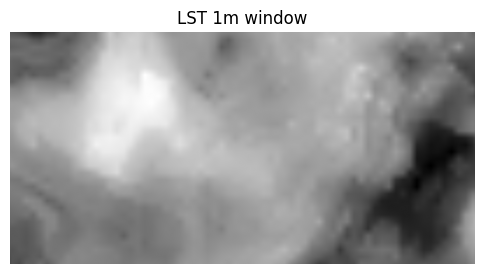

In [9]:
with rasterio.open(lst_predicted_fromglobal_1m_path) as src:
    lst_1m = src.read(1)

# Window within the bounds
xmin, ymin = 680000, 4945000
xmax, ymax = 682000, 4946000

# Convert bounds to pixel window
win = from_bounds(xmin, ymin, xmax, ymax, transform)

# Slices
r0, c0 = int(win.row_off), int(win.col_off)
r1 = r0 + int(win.height)
c1 = c0 + int(win.width)

# Extract window
r_win = lst_1m[r0:r1, c0:c1]

# Plot
plt.figure(figsize=(6,6))
plt.imshow(r_win, cmap="gray", origin="upper")
plt.title("LST 1m window")
plt.axis("off")
plt.show()

### MRT estimation


In [5]:
with rasterio.open(lst_predicted_fromglobal_1m_path) as lst_ref:
    meta = lst_ref.meta.copy()
    crs = lst_ref.crs
    transform = lst_ref.transform
    height = lst_ref.height
    width = lst_ref.width
    
    lst_arr = lst_ref.read(1).astype("float32")

with rasterio.open(shadow_raster_path) as sh_src:
    with WarpedVRT(sh_src, crs=crs, transform=transform,
                   width=width, height=height) as vrt:
        sh_arr = vrt.read(1).astype("float32")

with rasterio.open(distance_building_raster_path) as dist_src:
    with WarpedVRT(dist_src, crs=crs, transform=transform,
                   width=width, height=height) as vrt:
        dist_arr = vrt.read(1).astype("float32")

meta.update(dtype="float32", nodata=np.nan)

mrt_base = ((lst_arr + 2.5) / 0.79) - 15.27 * sh_arr

dist_capped = np.minimum(dist_arr, 16)
dist_safe = np.where(dist_capped > 0, dist_capped, 1)
mrt_final = mrt_base + 0.39 * (16 - dist_safe)


with rasterio.open(mrt_fromglobal_output_path, "w", **meta) as dst:
    dst.write(mrt_final, 1)

In [6]:
with rasterio.open(mrt_fromglobal_output_path) as src:
    mrt_plot = src.read(1) 

plt.figure(figsize=(8,8)) 
img = plt.imshow(mrt_plot, cmap="hot", origin="upper") #complete image, 1 minute aprox
plt.colorbar(label="MRT (°C)", shrink=0.8)
plt.axis("off")
plt.title("MRT en Bolonia el 09-08-2024 a las 11:58")
plt.show()


MemoryError: Unable to allocate 7.27 GiB for an array with shape (15071, 16183, 4) and data type float64

<Figure size 800x800 with 2 Axes>

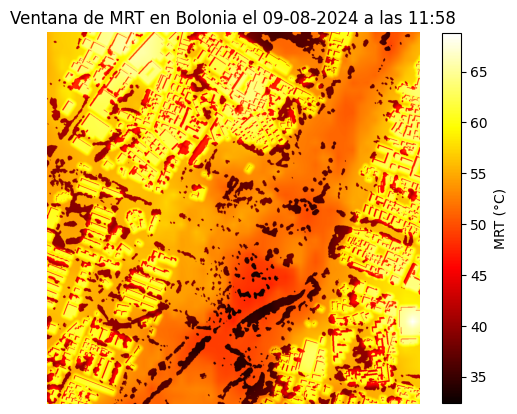

In [8]:
with rasterio.open(mrt_fromglobal_output_path) as src:
    mrt = src.read(1)
    transform = src.transform
    crs = src.crs

# Plot

xmin, ymin = 681000, 4945000
xmax, ymax = 682500, 4946500

win = from_bounds(xmin, ymin, xmax, ymax, transform) # Convert bounds to pixel window

# Slices
r0, c0 = int(win.row_off), int(win.col_off)
r1 = r0 + int(win.height)
c1 = c0 + int(win.width)

# Extract window
r_win = mrt[r0:r1, c0:c1]

# Plot
plt.figure(figsize=(6,6))
plt.imshow(r_win, cmap="hot", origin="upper")
plt.title("Ventana de MRT en Bolonia el 09-08-2024 a las 11:58")
plt.colorbar(label="MRT (°C)", shrink=0.8)
plt.axis("off")
plt.show()



### Extracting results for census areas

In [ ]:
with rasterio.open(mrt_fromglobal_output_path) as src:
    mrt_pred = src.read(1)
    mrt_transform = src.transform
    mrt_crs = src.crs
    
census_areas = gpd.read_file(census_areas_path)
census_areas = census_areas.to_crs(mrt_crs)

In [ ]:
# Extract statistics
stats = zonal_stats(
    census_areas,
    mrt_fromglobal_output_path,
    stats=["min", "max", "mean"],
    nodata=None  # or set the actual nodata if your raster has one
)

# Create a new GeoDataFrame with statistics + geometry
census_stats = gpd.GeoDataFrame({
    "min_MRT":  [s["min"]  for s in stats],
    "max_MRT":  [s["max"]  for s in stats],
    "mean_MRT": [s["mean"] for s in stats]
},
geometry=census_areas.geometry,
crs=census_areas.crs)


In [ ]:
census_stats.head()

In [ ]:
census_stats.to_file(os.path.join(base_dir, 'MRT-prediction/MRT_census_areas.gpkg'), driver="GPKG")

In [ ]:
gdf = gpd.read_file(os.path.join(base_dir, 'MRT-prediction/MRT_census_areas.gpkg'))

fig, ax = plt.subplots(figsize=(8,8))
gdf.plot(column="mean_MRT", cmap="hot", legend=True, ax=ax, linewidth=0, edgecolor="none", vmin=30, vmax=60)
ax.set_title("Mean MRT")
ax.set_axis_off()
plt.show()


In [ ]:
plt.figure(figsize=(12,4))

# Min
plt.subplot(1,3,1)
plt.hist(census_stats["min_MRT"].dropna(), bins=20, color="red")
plt.title("Min MRT")
plt.xlabel("MRT")
plt.ylabel("Frecuency")

# Mean
plt.subplot(1,3,2)
plt.hist(census_stats["mean_MRT"].dropna(), bins=20, color="orange")
plt.title("Avg MRT")
plt.xlabel("MRT")

# Max
plt.subplot(1,3,3)
plt.hist(census_stats["max_MRT"].dropna(), bins=20, color="darkred")
plt.title("Max MRT")
plt.xlabel("MRT")

plt.tight_layout()
plt.show()
